# README
## Purpose
Perform exploratory data analysis on the EODHD sample preprocessed model-input dataset.
## Inputs
- `Data/EODHD_sample_model_input.csv`
## Outputs
- Schema checks, descriptive statistics, keyword frequency plots, and wordcloud visualizations.
## Notes
Use this notebook for quality checks and exploratory insights before topic-model training.

## Imports

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import plotly.express as px
import re

## Read Data

In [2]:
eodhd_data = pd.read_csv('Data/EODHD_sample_model_input.csv')
eodhd_data['date'] = pd.to_datetime(eodhd_data['date'], errors='coerce')
if 'date_only' not in eodhd_data.columns:
    eodhd_data['date_only'] = eodhd_data['date'].dt.date

print('Loaded new dataset: Data/EODHD_sample_model_input.csv')

Loaded new dataset: Data/EODHD_sample_model_input.csv


## Quick schema check

In [3]:
print('eodhd shape:', eodhd_data.shape)
print('\neodhd columns:', list(eodhd_data.columns))
display(eodhd_data[['stock', 'headline', 'date', 'date_only']].head(2))

eodhd shape: (14604, 5)

eodhd columns: ['stock', 'date', 'date_only', 'headline', 'headline_raw']


,stock,headline,date,date_only
0,SAN,Banco __COMPANY__ SA __TICKER__ Q1 2025 Earnin...,2025-05-01 07:02:46+00:00,2025-05-01
1,MUFG,"Yen extends drop, BOJ hike bets fall as Ueda v...",2025-05-01 07:48:39+00:00,2025-05-01


## Exploratory data analysis

,missing_count
stock,0
headline,0
date_only,0


Date range combined: 2025-05-01 -> 2026-05-01
Unique stocks: 27


,n_records
stock,
C,981
MS,981
BCS,980
UBS,977
WFC,968
GS,959
BAC,953
JPM,952
HSBC,922


,headline_len_stats
count,14604.000000
mean,74.597371
std,22.580403
min,22.000000
25%,60.000000
50%,71.000000
75%,88.000000
max,296.000000


,date_only,n_records
352,2026-04-22,144
353,2026-04-23,113
354,2026-04-24,100
355,2026-04-25,54
356,2026-04-26,37
357,2026-04-27,149
358,2026-04-28,141
359,2026-04-29,135
360,2026-04-30,98
361,2026-05-01,26


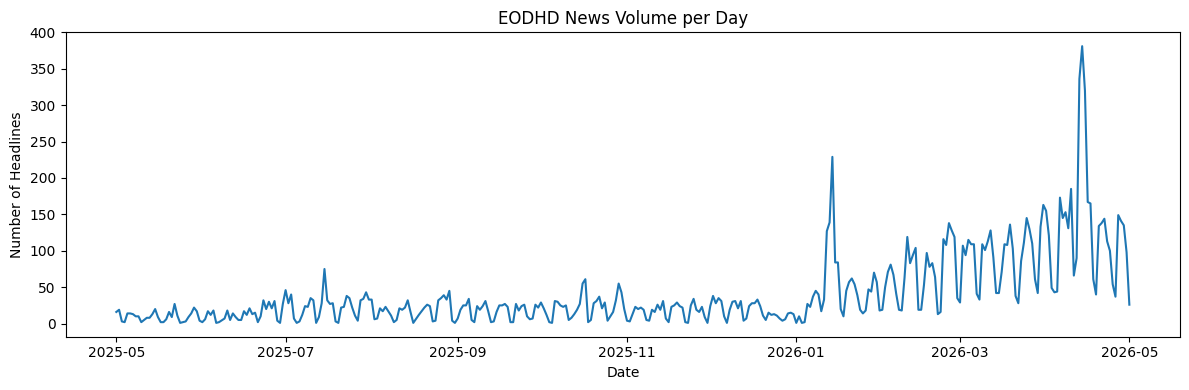

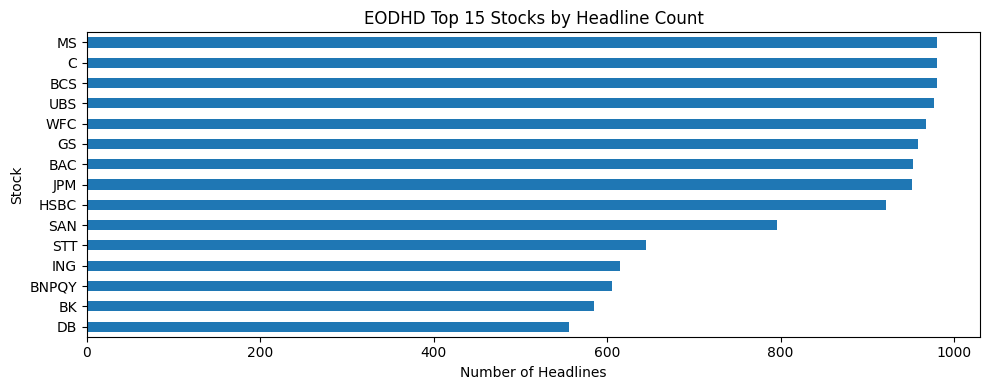

,date_only,n_records
344,2026-04-14,381
343,2026-04-13,336
345,2026-04-15,320
254,2026-01-14,229
340,2026-04-10,185
336,2026-04-06,173
346,2026-04-16,167
347,2026-04-17,165
330,2026-03-31,163
331,2026-04-01,155


In [4]:
# quality checks
display(eodhd_data[['stock', 'headline', 'date_only']].isna().sum().to_frame('missing_count'))
print('Date range combined:', eodhd_data['date_only'].min(), '->', eodhd_data['date_only'].max())
print('Unique stocks:', eodhd_data['stock'].nunique())

# top stocks
top_stocks = eodhd_data['stock'].value_counts().head(15)
display(top_stocks.rename_axis('stock').to_frame('n_records'))

# headline length
eodhd_data['headline_len'] = eodhd_data['headline'].str.len()
display(eodhd_data['headline_len'].describe().to_frame('headline_len_stats'))

# daily volume
daily_counts = eodhd_data.groupby('date_only').size().rename('n_records').reset_index()
display(daily_counts.tail(10))

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 4))
    plt.plot(pd.to_datetime(daily_counts['date_only']), daily_counts['n_records'])
    plt.title('EODHD News Volume per Day')
    plt.xlabel('Date')
    plt.ylabel('Number of Headlines')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    top_stocks.sort_values().plot(kind='barh')
    plt.title('EODHD Top 15 Stocks by Headline Count')
    plt.xlabel('Number of Headlines')
    plt.ylabel('Stock')
    plt.tight_layout()
    plt.show()
except Exception as error:
    print('Plotting skipped:', error)

# highest daily volume
daily_counts = eodhd_data.groupby('date_only').size().rename('n_records').reset_index().sort_values('n_records', ascending=False)
display(daily_counts.head(15))

## Wordcloud

Using text column for EDA/wordcloud: headline



Generating word cloud for headlines...


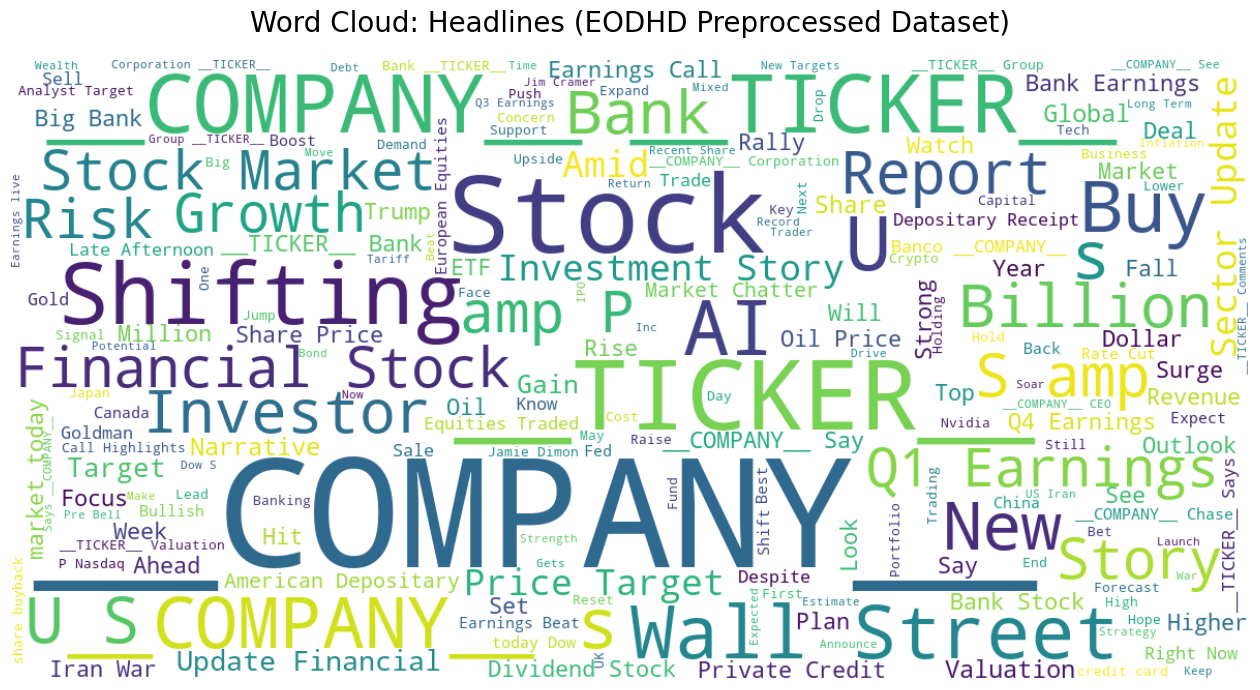

In [5]:
headline_col = 'headline'
print(f'Using text column for EDA/wordcloud: {headline_col}')

# Clean and extract keywords from titles
def extract_keywords(text):
    if pd.isna(text):
        return []
    words = re.findall(r'\b[a-z]{2,}\b', str(text).lower())
    stop_words = {'we', 'il', 'll', 'as', 'it', 'vs', 'at', 'be', 'our', 'use', 'or', 'let', 'but', 'us', 'by', 'more', 'come', 'have', 'the', 'and', 'for', 'with', 'how', 'your', 'using', 'from', 'into', 'this', 'that', 'are', 'was', 'you', 'what', 'can', 'in', 'to', 'of', 'is', 'an', 'do', 'de', 'on', 'not', 'why', 'will'}
    return [w for w in words if w not in stop_words]

all_summary_words = []
for summary in eodhd_data[headline_col].dropna():
    all_summary_words.extend(extract_keywords(summary))

summary_word_freq = Counter(all_summary_words)
top_summary_words = pd.DataFrame(summary_word_freq.most_common(20), columns=['keyword', 'frequency'])

fig2 = px.bar(
    top_summary_words,
    x='keyword',
    y='frequency',
    title='Top 20 Keywords in Headlines (GSIB Preprocessed Dataset)',
    labels={'keyword': 'Keyword', 'frequency': 'Frequency'},
    color='frequency',
    color_continuous_scale='Viridis'
 )
fig2.update_layout(showlegend=False, height=500)
fig2.show(renderer='iframe')

print("\nGenerating word cloud for headlines...")
title_text = ' '.join(eodhd_data[headline_col].dropna().astype(str))
wordcloud_title = WordCloud(width=1200, height=600, background_color='white', colormap='viridis').generate(title_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_title, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Headlines (EODHD Preprocessed Dataset)', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [6]:
# Average headline length (characters + words)
import pandas as pd

if 'eodhd_data' in globals() and 'headline' in eodhd_data.columns:
    headlines = eodhd_data['headline'].dropna().astype(str)
else:
    tmp_df = pd.read_csv('Data/EODHD_model_input.csv')
    headlines = tmp_df['headline'].dropna().astype(str)

avg_chars = headlines.str.len().mean()
avg_words = headlines.str.split().str.len().mean()
std_words = headlines.str.split().str.len().std()
min_words = headlines.str.split().str.len().min()
max_words = headlines.str.split().str.len().max()

print(f"Headlines analyzed: {len(headlines):,}")
print(f"Average headline length: {avg_chars:.2f} characters")
print(f"Average headline length: {avg_words:.2f} words")
print(f"Headline length standard deviation: {std_words:.2f} words")
print(f"Minimum headline length: {min_words} words")
print(f"Maximum headline length: {max_words} words")

Headlines analyzed: 14,604
Average headline length: 74.60 characters
Average headline length: 11.51 words
Headline length standard deviation: 3.49 words
Minimum headline length: 4 words
Maximum headline length: 44 words
